# UAE E-Commerce Fraud Signal Analysis
## Phase 2: Exploratory Data Analysis

This notebook forms the second phase of a three-part fraud analytics project. 
The analysis is written from the perspective of a fraud analytics analyst 
at a UAE e-commerce payments company.

**Goal:** Visualize and validate the signal patterns identified in the SQL phase, 
explore distributions and correlations, and prepare features for the ML 
classification model.

**Dataset:** 100,000 synthetic UAE e-commerce transactions | Fraud rate: 8.21%

**Audience:** Risk team at a payments company — findings are translated into 
actionable detection recommendations throughout.

In [84]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
%matplotlib inline

## Data Loading and Overview
*What does the dataset look like and is it loaded correctly?*

In [85]:

fraud_df = pd.read_csv('uae_ecom_fraud_100k.csv')

# Quick overview
print("Shape:", fraud_df.shape)
print("\nColumn names:\n", fraud_df.columns.tolist())
print("\nData types:\n", fraud_df.dtypes)
print("\nFirst 5 rows:\n", fraud_df.head())

Shape: (100000, 36)

Column names:
 ['transaction_id', 'user_id', 'timestamp_utc', 'amount_aed', 'currency', 'payment_method', 'device_type', 'browser', 'merchant_category', 'items_count', 'avg_item_price', 'shipping_city', 'billing_city', 'shipping_billing_match', 'ip_address', 'ip_risk_score', 'card_present', 'bin_country', 'card_age_days', 'card_country_match', 'email_domain', 'user_prev_chargebacks', 'user_is_high_risk', 'user_account_age_days', 'transactions_last_24h', 'transactions_last_1h', 'local_hour', 'odd_hour', 'is_fraud', 'fraud_flag_ip', 'fraud_flag_mismatch', 'fraud_flag_velocity', 'fraud_flag_new_account', 'fraud_flag_prev_cb', 'fraud_flag_odd_hour', 'data_source']

Data types:
 transaction_id              int64
user_id                     int64
timestamp_utc              object
amount_aed                float64
currency                   object
payment_method             object
device_type                object
browser                    object
merchant_category       

### Insight
Dataset loaded successfully — 100,000 rows and 36 columns confirmed. 
All expected columns present. No immediate loading errors.
Full quality assessment follows in the cleaning section.

## Missing Values and Class Balance
*Does the dataset have missing values and how balanced is the fraud label?*

In [86]:
# Missing values
print("Missing values:\n", fraud_df.isnull().sum())

# Class balance
print("\nFraud distribution:")
print(fraud_df['is_fraud'].value_counts())
print("\nFraud rate:", round(fraud_df['is_fraud'].mean() * 100, 2), "%")


Missing values:
 transaction_id            0
user_id                   0
timestamp_utc             0
amount_aed                0
currency                  0
payment_method            0
device_type               0
browser                   0
merchant_category         0
items_count               0
avg_item_price            0
shipping_city             0
billing_city              0
shipping_billing_match    0
ip_address                0
ip_risk_score             0
card_present              0
bin_country               0
card_age_days             0
card_country_match        0
email_domain              0
user_prev_chargebacks     0
user_is_high_risk         0
user_account_age_days     0
transactions_last_24h     0
transactions_last_1h      0
local_hour                0
odd_hour                  0
is_fraud                  0
fraud_flag_ip             0
fraud_flag_mismatch       0
fraud_flag_velocity       0
fraud_flag_new_account    0
fraud_flag_prev_cb        0
fraud_flag_odd_hour       0
dat

### Insight
No missing values across all 36 columns — the dataset is complete and 
requires no imputation.

The fraud label is imbalanced — 91,789 legitimate transactions (91.79%) 
versus 8,211 fraudulent ones (8.21%). This is a realistic fraud rate for 
e-commerce and is better balanced than many real-world fraud datasets. 
However the imbalance is still meaningful and will need to be addressed 
during the ML phase — techniques such as class weighting or resampling 
may be required to prevent the model from simply predicting legitimate 
for every transaction.

## Data Cleaning
*What data quality issues exist and how should they be handled?*

In [87]:

# 1. Convert timestamp to datetime
fraud_df['timestamp_utc'] = pd.to_datetime(fraud_df['timestamp_utc'])

# 2. Drop data_source column - same value for all rows, adds nothing
fraud_df = fraud_df.drop(columns=['data_source'])

# 3. Flag negative account age days as a data quality note
negative_account_age = fraud_df[fraud_df['user_account_age_days'] < 0].shape[0]
print(f"Rows with negative account age days: {negative_account_age}")
print(f"This represents {round(negative_account_age / len(fraud_df) * 100, 2)}% of transactions")
print(f"\nUpdated shape after dropping data_source: {fraud_df.shape}")

Rows with negative account age days: 16606
This represents 16.61% of transactions

Updated shape after dropping data_source: (100000, 35)


In [88]:
# Investigate negative account age days
print("Negative account age stats:")
print(fraud_df[fraud_df['user_account_age_days'] < 0]['user_account_age_days'].describe())

print("\nFraud rate for negative account age transactions:")
neg_age = fraud_df[fraud_df['user_account_age_days'] < 0]
print(f"Fraud rate: {round(neg_age['is_fraud'].mean() * 100, 2)}%")

print("\nFraud rate for positive account age transactions:")
pos_age = fraud_df[fraud_df['user_account_age_days'] >= 0]
print(f"Fraud rate: {round(pos_age['is_fraud'].mean() * 100, 2)}%")

Negative account age stats:
count   16606.00
mean     -185.83
std       106.80
min      -365.00
25%      -280.00
50%      -187.00
75%       -93.00
max        -1.00
Name: user_account_age_days, dtype: float64

Fraud rate for negative account age transactions:
Fraud rate: 12.75%

Fraud rate for positive account age transactions:
Fraud rate: 7.31%


In [89]:
# Create a flag for negative account age rather than dropping or fixing
# Negative values likely reflect a data generation artifact in this
# synthetic dataset but show a higher fraud rate (12.75% vs 7.31%)
# so the signal is worth preserving as a binary feature for ML

fraud_df['account_age_negative'] = (fraud_df['user_account_age_days'] < 0).astype(int)

print("Flag created — account_age_negative distribution:")
print(fraud_df['account_age_negative'].value_counts())
print(f"\nUpdated shape: {fraud_df.shape}")

Flag created — account_age_negative distribution:
account_age_negative
0    83394
1    16606
Name: count, dtype: int64

Updated shape: (100000, 36)


### Insight
Three cleaning steps were applied:

1. `timestamp_utc` converted from object to datetime for time-based analysis
2. `data_source` dropped — identical value across all 100,000 rows, adds no analytical value
3. `user_account_age_days` has 16,606 negative values (16.61%) — likely a data 
   generation artifact in this synthetic dataset. Rather than dropping these rows, 
   a binary flag `account_age_negative` was created to preserve the signal, as 
   negative account age transactions show a notably higher fraud rate (12.75% vs 7.31%).

**Updated shape after cleaning:** 100,000 rows, 36 columns (data_source dropped, 
account_age_negative added)

## Transaction Class Balance
*How many transactions are fraudulent versus legitimate?*

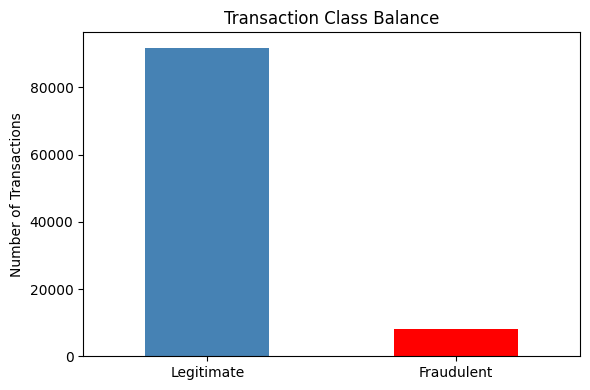

In [90]:

# Class balance
ax = fraud_df['is_fraud'].value_counts().plot(kind='bar', figsize=(6, 4), 
                                               color=['steelblue', 'red'])
ax.set_title('Transaction Class Balance')
ax.set_ylabel('Number of Transactions')
ax.set_xticklabels(['Legitimate', 'Fraudulent'], rotation=0)
ax.set_xlabel('')
plt.tight_layout()
plt.savefig('01_class_balance.png', dpi=150)
plt.show()

### Insight
The dataset contains 91,789 legitimate transactions (91.79%) and 8,211 
fraudulent ones (8.21%). While imbalanced, this is a realistic fraud rate 
for e-commerce — far more balanced than many real-world fraud datasets 
which can have fraud rates below 0.1%.

The class imbalance will need to be addressed during the ML phase. 
A model that predicts every transaction as legitimate would achieve 
91.79% accuracy while catching zero fraud — accuracy alone is therefore 
not a useful metric for this problem. Precision, recall, and F1 score 
will be the primary evaluation metrics in Phase 3.

## IP Risk Score Distribution
*Do fraudulent transactions have higher IP risk scores than legitimate ones?*

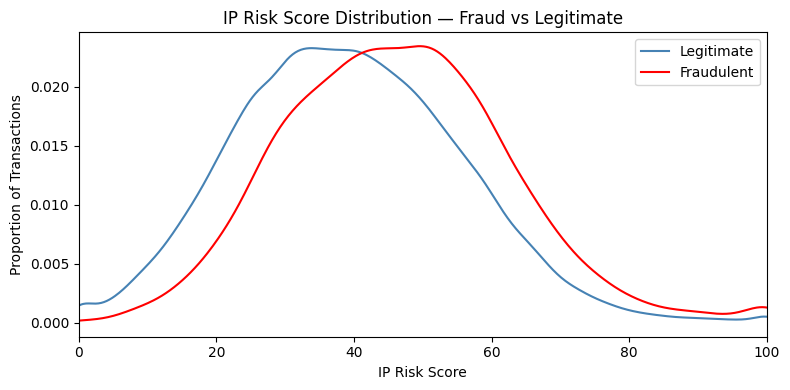

In [91]:

fraud_df[fraud_df['is_fraud'] == 0]['ip_risk_score'].plot(
    kind='kde', color='steelblue', label='Legitimate', figsize=(8, 4))
fraud_df[fraud_df['is_fraud'] == 1]['ip_risk_score'].plot(
    kind='kde', color='red', label='Fraudulent')

plt.title('IP Risk Score Distribution — Fraud vs Legitimate')
plt.xlabel('IP Risk Score')
plt.ylabel('Proportion of Transactions')
plt.xlim(0, 100)
plt.legend()
plt.tight_layout()
plt.savefig('02_ip_risk_score_kde.png', dpi=150)
plt.show()

### Insight
Fraudulent transactions shift noticeably to the right — peaking around 
45-50 compared to legitimate transactions which peak around 30-35.

This confirms the SQL finding that fraudulent transactions carry a higher 
average IP risk score (46.25 vs 39.24). The visual shift reinforces that 
IP risk score is a reliable signal for the risk team — higher scores are 
disproportionately associated with fraud.

For the risk team, IP risk score should be incorporated into the fraud 
scoring model. Transactions above a defined threshold should trigger 
step-up authentication such as OTP or 3D Secure verification.

## Transaction Amount Distribution
*Do fraudulent transactions skew toward higher amounts than legitimate ones?*

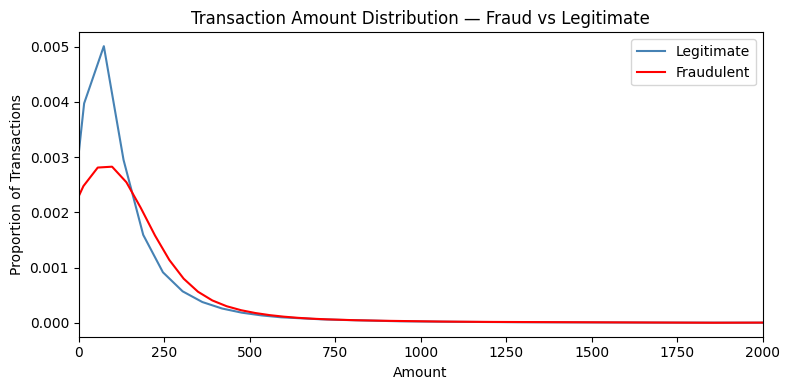

In [92]:

fraud_df[fraud_df['is_fraud'] == 0]['amount_aed'].plot(
    kind='kde', color='steelblue', label='Legitimate', figsize=(8, 4))
fraud_df[fraud_df['is_fraud'] == 1]['amount_aed'].plot(
    kind='kde', color='red', label='Fraudulent')

plt.title('Transaction Amount Distribution — Fraud vs Legitimate')
plt.xlabel('Amount')
plt.ylabel('Proportion of Transactions')
plt.xlim(0, 2000)
plt.legend()
plt.tight_layout()
plt.savefig('03_amount_transaction_kde.png', dpi=150)
plt.show()

### Insight
The distribution contradicts the SQL average finding. While SQL showed 
fraudulent transactions had a higher average amount (198.31 AED vs 159.69 AED), 
the KDE shows fraudulent transactions actually cluster at lower amounts — 
the fraud peak sits noticeably to the left of the legitimate peak.

This contradiction is explained by outliers. A small number of high-value 
fraudulent transactions pull the SQL average up, masking the fact that 
most fraudulent transactions are relatively small.

This is consistent with a common fraud behavior pattern — fraudsters tend 
to make smaller transactions to avoid triggering detection rules and to 
stay within the cardholder's available balance.

For the risk team, transaction amount should not be used as a standalone 
fraud trigger. Flagging high-value transactions would miss the majority 
of fraud. Amount is most useful as a contextual signal combined with 
stronger indicators such as IP risk score or geographic mismatch.

## Categorical Signal Analysis
*Does fraud concentrate in specific merchant categories, device types, or payment methods?*

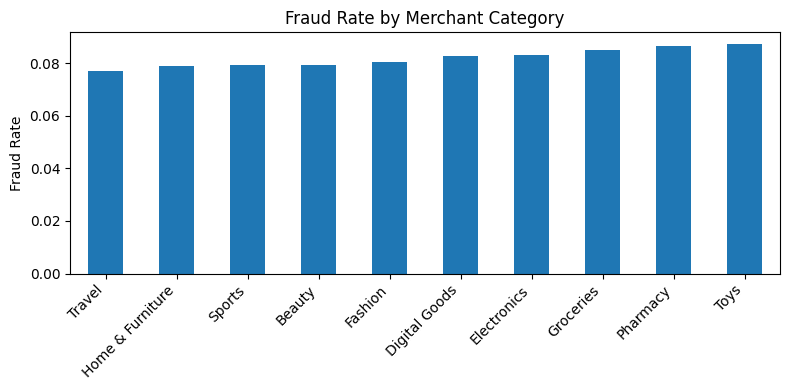

In [93]:
ax = fraud_df.groupby('merchant_category')['is_fraud'].mean().sort_values().plot(kind='bar', figsize=(8, 4))
ax.set_title('Fraud Rate by Merchant Category')
ax.set_ylabel('Fraud Rate')
ax.set_xlabel('')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('04_merchant_category.png', dpi=150)
plt.show()

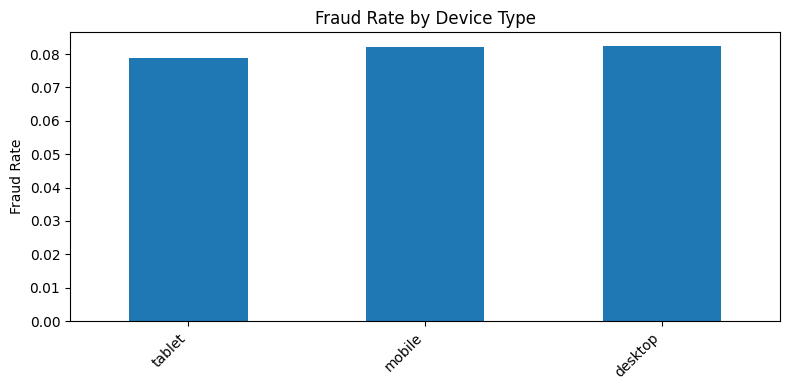

In [94]:
ax = fraud_df.groupby('device_type')['is_fraud'].mean().sort_values().plot(kind='bar', figsize=(8, 4))
ax.set_title('Fraud Rate by Device Type')
ax.set_ylabel('Fraud Rate')
ax.set_xlabel('')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('05_device_type.png', dpi=150)
plt.show()

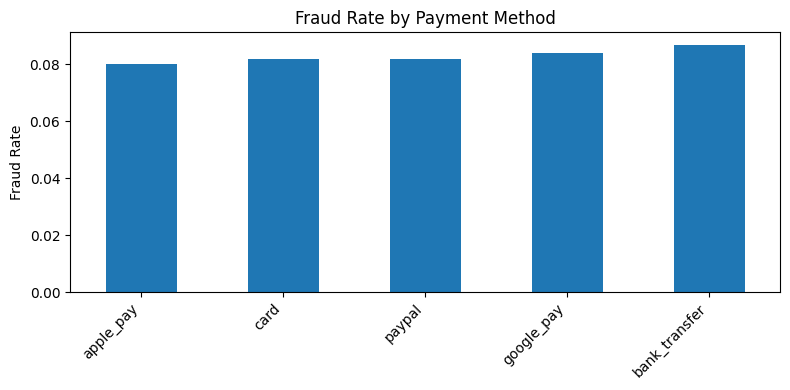

In [95]:
ax = fraud_df.groupby('payment_method')['is_fraud'].mean().sort_values().plot(kind='bar', figsize=(8, 4))
ax.set_title('Fraud Rate by Payment Method')
ax.set_ylabel('Fraud Rate')
ax.set_xlabel('')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('06_payment_method.png', dpi=150)
plt.show()

### Insight
All three categorical variables tell the same story — fraud is distributed 
almost evenly across all groups with differences too small to act on:

- **Merchant category** — spread of just 1% (7.70% to 8.73%)
- **Device type** — spread of less than 0.4% (7.88% to 8.24%)
- **Payment method** — spread of less than 0.7% (8.03% to 8.69%)

For the risk team, do not build fraud rules based on merchant category, 
device type, or payment method alone. These variables should only be 
considered as weak supporting signals in combination with stronger 
indicators identified in later sections.

## Geographic Mismatch Analysis
*Does fraud rate increase when card country and shipping/billing addresses do not match?*

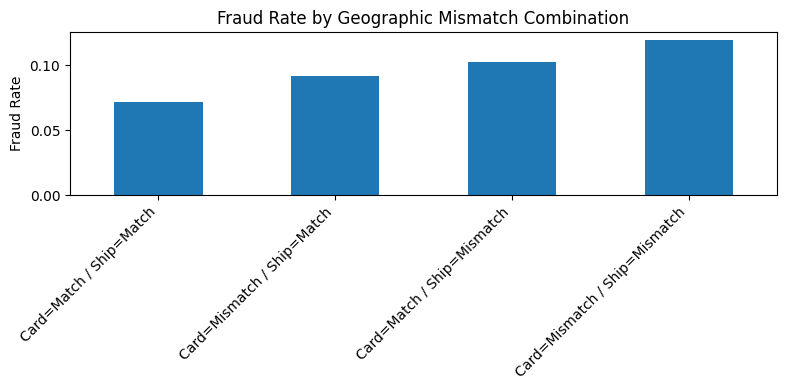

In [96]:
# Create readable labels for each combination
fraud_df['geo_mismatch'] = fraud_df.apply(
    lambda x: f"Card={'Match' if x['card_country_match'] == 1 else 'Mismatch'} / "
              f"Ship={'Match' if x['shipping_billing_match'] == 1 else 'Mismatch'}", axis=1)

# Plot fraud rate by combination
ax = fraud_df.groupby('geo_mismatch')['is_fraud'].mean().sort_values().plot(
    kind='bar', figsize=(8, 4))
ax.set_title('Fraud Rate by Geographic Mismatch Combination')
ax.set_ylabel('Fraud Rate')
ax.set_xlabel('')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('07_geographic_mismatch.png', dpi=150)
plt.show()

### Insight
Fraud rate increases consistently as mismatches accumulate:

- **Both match** — lowest fraud rate (7.21%)
- **Card mismatch only** — moderate fraud rate (9.16%)
- **Shipping mismatch only** — elevated fraud rate (10.30%)
- **Both mismatch** — highest fraud rate (11.96%)

Each additional mismatch raises the fraud rate, confirming that geographic 
inconsistency is a genuine signal rather than noise. When both mismatches 
are present, the transaction is nearly 5 percentage points more likely 
to be fraudulent than a fully matched transaction.

For the risk team, double mismatch transactions should be flagged for 
step-up authentication. Single mismatches warrant a moderate risk score 
increase rather than outright blocking, to avoid friction on legitimate 
cross-border purchases.

## User Risk Profile Analysis
*Do high risk users have higher fraud rates and what proportion of total fraud do they represent?*

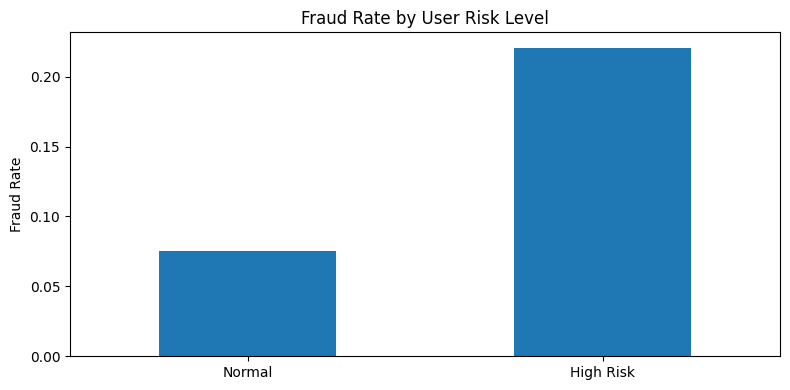

In [97]:
ax = fraud_df.groupby('user_is_high_risk')['is_fraud'].mean().sort_values().plot(kind='bar', figsize=(8, 4))
ax.set_title('Fraud Rate by User Risk Level')
ax.set_ylabel('Fraud Rate')
ax.set_xlabel('')
ax.set_xticklabels(['Normal', 'High Risk'], rotation=0)
plt.tight_layout()
plt.savefig('08_highrisk_vs_normalusers.png', dpi=150)
plt.show()

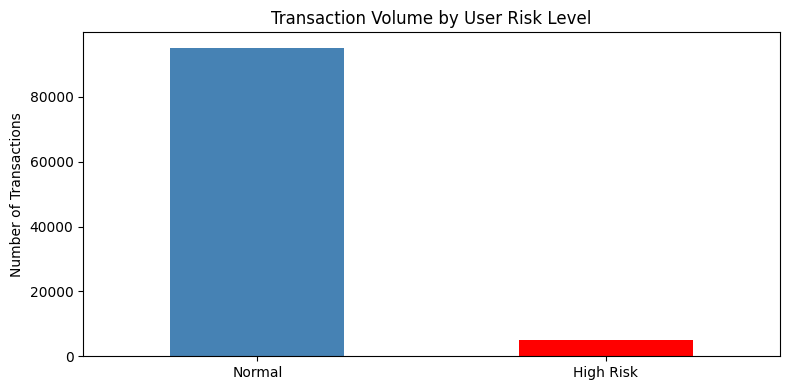

In [98]:
ax = fraud_df.groupby('user_is_high_risk')['is_fraud'].count().plot(
    kind='bar', figsize=(8, 4), color=['steelblue', 'red'])
ax.set_title('Transaction Volume by User Risk Level')
ax.set_ylabel('Number of Transactions')
ax.set_xlabel('')
ax.set_xticklabels(['Normal', 'High Risk'], rotation=0)
plt.tight_layout()
plt.savefig('09_highrisk_volume.png', dpi=150)
plt.show()

### Insight
Two charts are needed to tell the complete story of the user risk flag.

The first chart shows high risk users have a significantly higher fraud 
rate (22.07%) compared to normal users (7.50%) — nearly three times higher. 
This makes the high risk flag the strongest single signal identified 
in this analysis.

However the second chart reveals the critical limitation. High risk users 
account for only 4,871 of 100,000 transactions — a tiny fraction of total 
volume. This means 86.91% of all fraudulent transactions come from users 
not flagged as high risk.

For the risk team, the high risk flag should trigger immediate intervention 
when present but cannot be the foundation of the detection system. It must 
be combined with transaction-level signals to catch the majority of fraud 
that occurs outside the flagged user segment.

## User Account Age Analysis
*Do fraudulent transactions tend to come from newer accounts?*

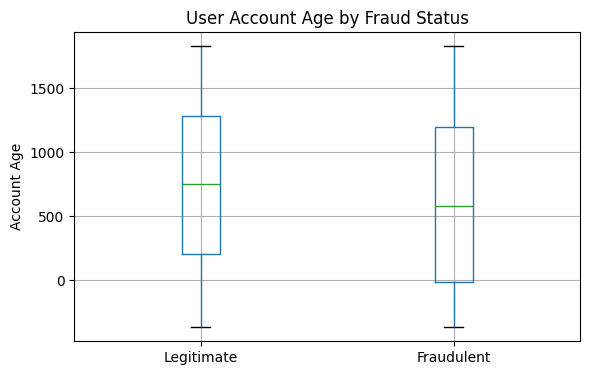

In [99]:
fig, ax = plt.subplots(figsize=(6, 4))

fraud_df.boxplot(column='user_account_age_days', by='is_fraud', ax=ax)
ax.set_title('User Account Age by Fraud Status')
ax.set_xlabel('')
ax.set_ylabel('Account Age')
ax.set_xticklabels(['Legitimate', 'Fraudulent'])
plt.suptitle('')
plt.tight_layout()
plt.savefig('10_user_account_age_boxplot.png', dpi=150)
plt.show()

### Insight
The boxplot shows fraudulent transactions tend to come from newer accounts. 
The median account age for fraudulent transactions is noticeably lower than 
for legitimate ones, and the interquartile range is compressed toward 
lower values for fraud.

This is consistent with a common fraud pattern where accounts are created 
specifically to commit fraud and then abandoned. It provides visual evidence 
supporting the SQL finding that fraud_flag_new_account had a 12.69% fraud 
rate when fired.

Note: Both groups show negative account age values — a data generation 
artifact in this synthetic dataset. These were preserved as a binary flag 
(account_age_negative) rather than removed, as they showed a higher fraud 
rate (12.75% vs 7.31%).

For the risk team, account age should be monitored as a supporting signal. 
Very new accounts placing high-value transactions or triggering other 
signals should receive additional scrutiny.

## Previous Chargebacks Analysis
*Do fraudulent transactions come from users with more previous chargebacks?*

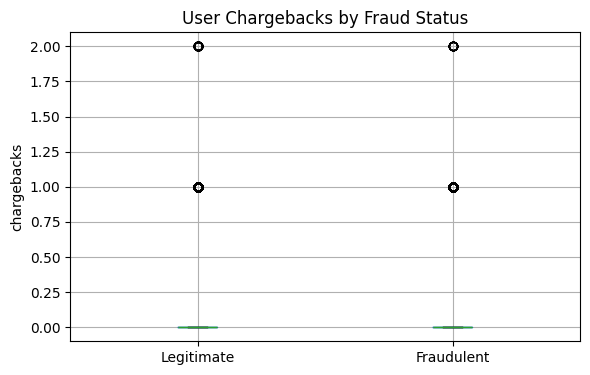

In [100]:
fig, ax = plt.subplots(figsize=(6, 4))

fraud_df.boxplot(column='user_prev_chargebacks', by='is_fraud', ax=ax)
ax.set_title('User Chargebacks by Fraud Status')
ax.set_xlabel('')
ax.set_ylabel('chargebacks')
ax.set_xticklabels(['Legitimate', 'Fraudulent'])
plt.suptitle('')
plt.tight_layout()
plt.savefig('11_user_prev_chargeback_boxplot.png', dpi=150)
plt.show()

### Insight
Both fraudulent and legitimate transactions are almost entirely concentrated 
at zero chargebacks — the median, Q1, and Q3 for both groups sit at zero, 
with outliers only at 1 and 2.

This explains why previous chargebacks appeared weak in the SQL average 
analysis. The average difference (0.10 vs 0.02) was driven by a very small 
number of users with any chargeback history at all.

However this does not contradict the SQL Section G finding that prev_cb_flag 
has a 27.24% fraud rate when it fires. The flag fires rarely but with high 
precision — the boxplot shows why. Most users have no chargeback history, 
so when the flag does fire it is genuinely informative.

For the risk team, previous chargebacks should not trigger fraud rules 
independently. It is a high precision, low coverage signal most useful 
as a tiebreaker when combined with other active signals.

## Card Age Analysis
*Does card age differ between fraudulent and legitimate transactions?*

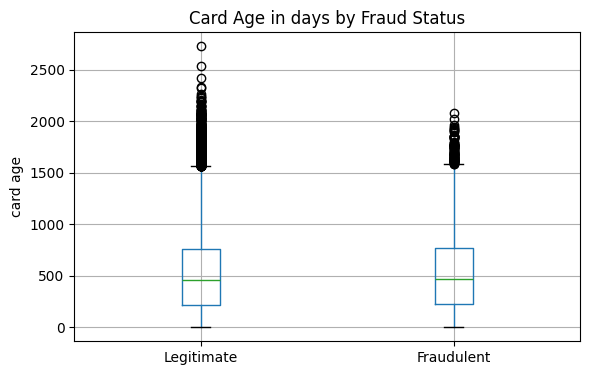

In [101]:
fig, ax = plt.subplots(figsize=(6, 4))

fraud_df.boxplot(column='card_age_days', by='is_fraud', ax=ax)
ax.set_title('Card Age in days by Fraud Status')
ax.set_xlabel('')
ax.set_ylabel('card age')
ax.set_xticklabels(['Legitimate', 'Fraudulent'])
plt.suptitle('')
plt.tight_layout()
plt.savefig('12_card_age_days_boxplot.png', dpi=150)
plt.show()

### Insight
Card age does not meaningfully differ between fraudulent and legitimate 
transactions. Both groups share a similar median around 450-500 days 
and comparable interquartile ranges.

The main visible difference is that legitimate transactions include more 
extreme outliers — cards aged 2,000+ days — suggesting long-standing 
customers with old cards skew slightly toward legitimate behavior. 
Fraudulent transactions show a more compact distribution with fewer 
very old cards.

The overall similarity between the two distributions confirms that card 
age is not a reliable standalone fraud signal and was correctly excluded 
from the SQL signal ranking.

## Time-Based Fraud Analysis
*Does fraud concentrate at specific hours of the day?*

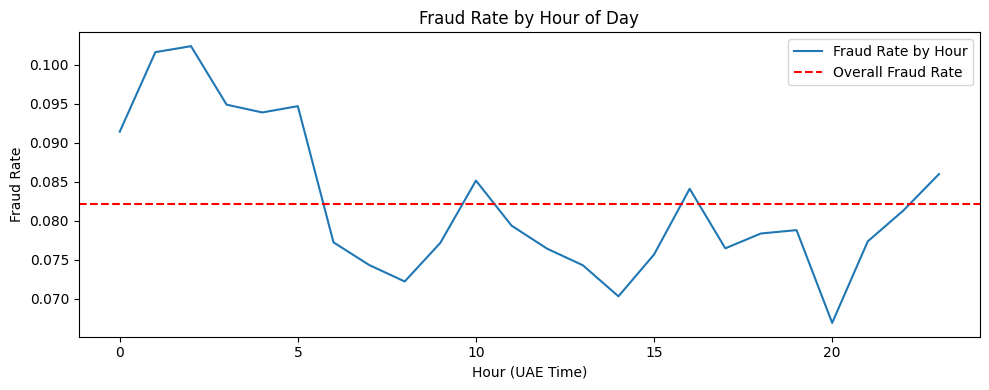

In [102]:
ax = fraud_df.groupby('local_hour')['is_fraud'].mean().plot(kind='line', figsize=(10, 4), label = 'Fraud Rate by Hour')
ax.axhline(y=fraud_df['is_fraud'].mean(), color='red', linestyle='--', label='Overall Fraud Rate')
ax.set_title('Fraud Rate by Hour of Day')
ax.set_ylabel('Fraud Rate')
ax.set_xlabel('Hour (UAE Time)')
ax.legend()
plt.tight_layout()
plt.savefig('13_fraudrate_by_hour.png', dpi=150)
plt.show()

### Insight

The line chart confirms the SQL finding that fraud concentrates in the 
early morning hours. Hours 0 through 5 (midnight to 5am UAE time) 
consistently sit above the overall fraud rate reference line (8.21%), 
peaking at approximately 10.24% around 2am.

From 6am onwards, fraud rates drop below the average and remain lower 
throughout the afternoon and evening, with the lowest point around 
8pm before a slight uptick late at night.

While the overall spread is less than 4 percentage points across all 
24 hours — confirming that time alone is not a strong standalone signal — 
the consistent elevation in early morning hours is a directionally 
meaningful pattern.

For the risk team, transactions between midnight and 5am UAE time should 
receive a modest risk score increase, particularly when combined with 
other active signals such as elevated IP risk score or geographic mismatch. 
The odd_hour boolean flag already captures this window and is the simplest 
variable to implement in a real-time scoring system.

## Fraud Flag Analysis
*Which fraud flags are most reliable and what happens when multiple flags fire together?*

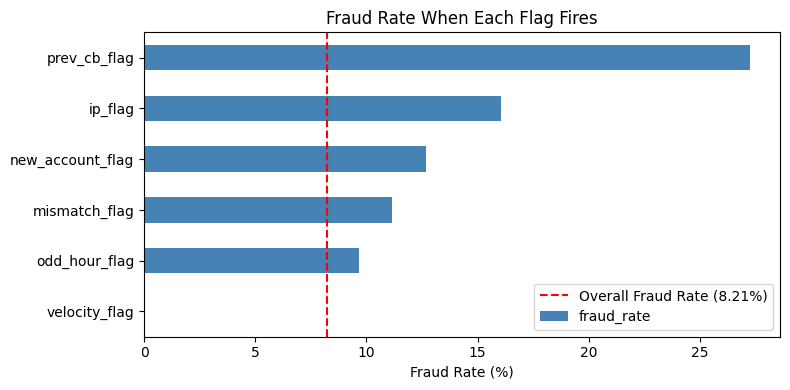

In [103]:
flag_reliability = pd.DataFrame({
    'flag': ['prev_cb_flag', 'ip_flag', 'new_account_flag', 
             'mismatch_flag', 'odd_hour_flag', 'velocity_flag'],
    'fraud_rate': [27.24, 16.05, 12.69, 11.13, 9.65, 0.00]
})

ax = flag_reliability.sort_values('fraud_rate').plot(
    kind='barh', x='flag', y='fraud_rate', 
    figsize=(8, 4), legend=False, color='steelblue')
ax.set_title('Fraud Rate When Each Flag Fires')
ax.set_xlabel('Fraud Rate (%)')
ax.set_ylabel('')
ax.axvline(x=8.21, color='red', linestyle='--', label='Overall Fraud Rate (8.21%)')
ax.legend()
plt.tight_layout()
plt.savefig('14_flag_reliability.png', dpi=150)
plt.show()

### Insight — Flag Reliability
All flags except velocity_flag perform above the overall fraud rate when 
fired, confirming they carry genuine signal.

prev_cb_flag is the highest precision signal at 27.24% — more than three 
times the overall fraud rate. ip_flag follows at 16.05%, with new_account_flag 
and mismatch_flag at moderate levels. odd_hour_flag barely clears the 
reference line at 9.65%, confirming it is the weakest flag. velocity_flag 
never fires — a data quality issue confirmed throughout the analysis.

The key distinction is frequency vs precision. A flag that fires rarely 
but reliably is more actionable than one that fires constantly with weak 
discrimination.

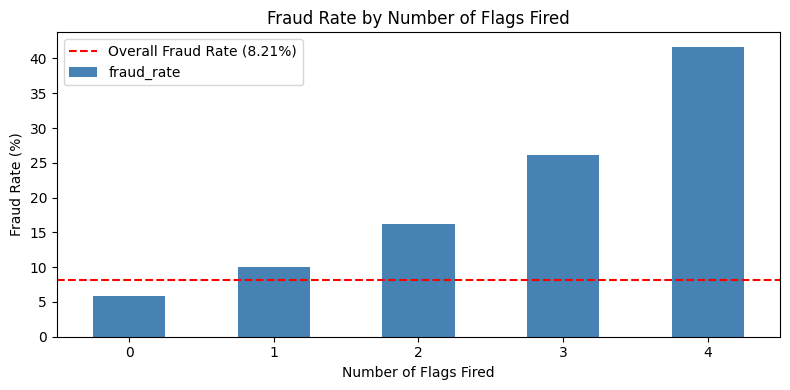

In [104]:
flag_combinations = pd.DataFrame({
    'flags_fired': [0, 1, 2, 3, 4],
    'fraud_rate': [5.84, 9.96, 16.15, 26.15, 41.67]
})

ax = flag_combinations.plot(
    kind='bar', x='flags_fired', y='fraud_rate',
    figsize=(8, 4), legend=False, color='steelblue')
ax.set_title('Fraud Rate by Number of Flags Fired')
ax.set_xlabel('Number of Flags Fired')
ax.set_ylabel('Fraud Rate (%)')
ax.set_xticklabels([0, 1, 2, 3, 4], rotation=0)
ax.axhline(y=8.21, color='red', linestyle='--', label='Overall Fraud Rate (8.21%)')
ax.legend()
plt.tight_layout()
plt.savefig('15_flag_combinations.png', dpi=150)
plt.show()

### Insight — Flag Combinations
Fraud rate increases dramatically as more flags fire together:

- 0 flags: 5.84% — below average
- 1 flag: 9.96% — slightly above average
- 2 flags: 16.15% — double the baseline
- 3 flags: 26.15% — more than three times the baseline
- 4 flags: 41.67% — five times the baseline

Each additional flag approximately doubles the fraud rate, confirming 
that flags compound each other's predictive power.

Critically, 39.65% of all fraud (3,256 of 8,211 transactions) occurs 
in transactions with zero flags fired. This is the primary justification 
for the ML phase — rule-based systems alone cannot close this coverage gap.

For the risk team, transactions with 3 or more flags fired should be 
treated as high priority for immediate review or blocking. Transactions 
with 2 flags warrant step-up authentication.

## Correlation Heatmap
*How do numeric variables relate to each other and which are most correlated with fraud?*

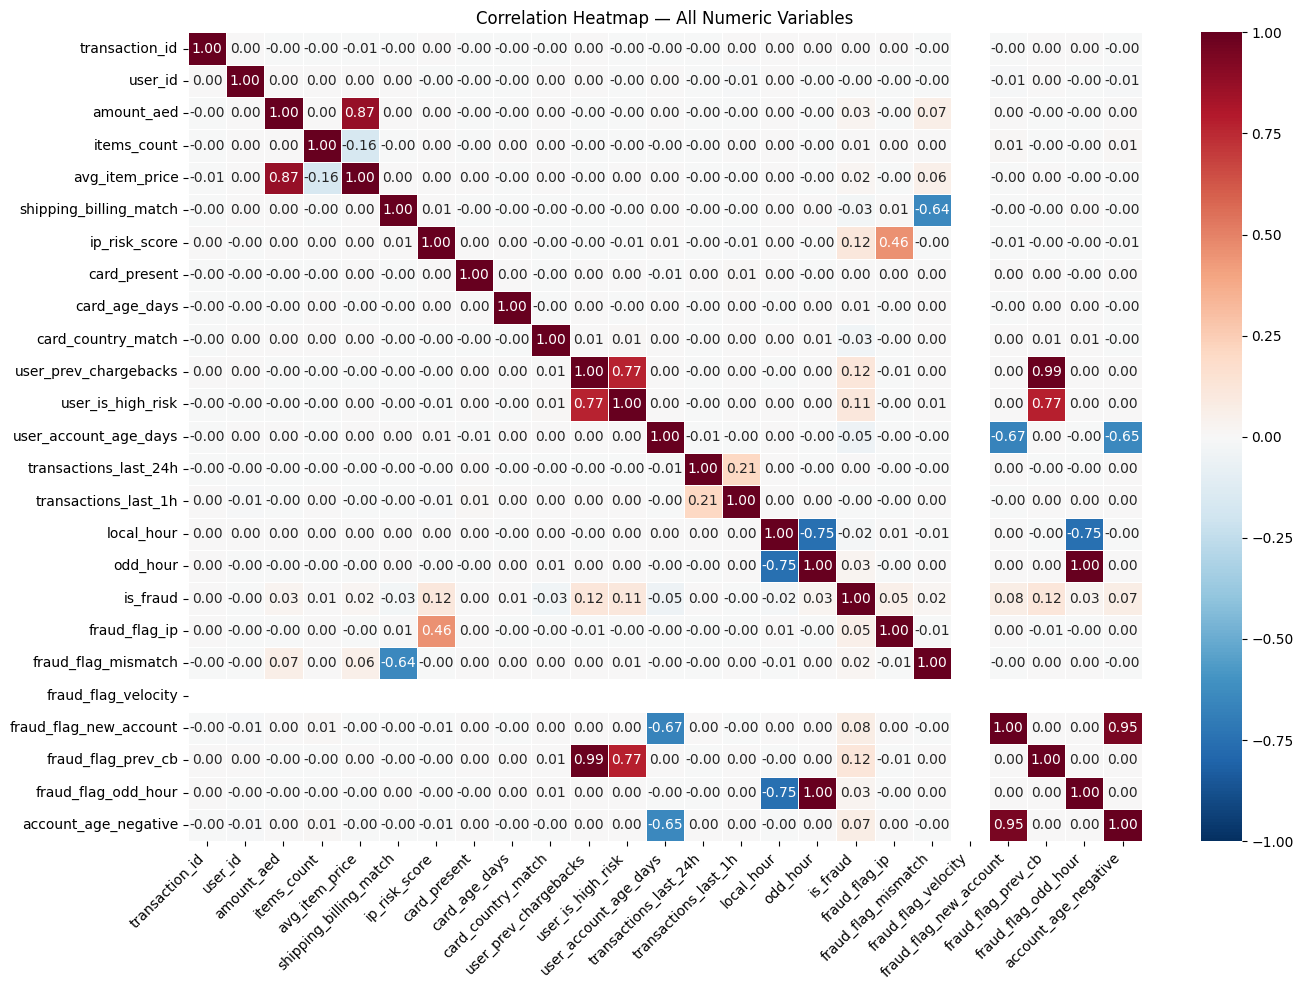

In [105]:
# Select numeric columns only
numeric_cols = fraud_df.select_dtypes(include='number').columns.tolist()

# Calculate correlation matrix
corr_matrix = fraud_df[numeric_cols].corr()

# Plot heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, 
            annot=True, 
            fmt='.2f', 
            cmap='RdBu_r',
            center=0,
            vmin=-1, vmax=1,
            linewidths=0.5)
plt.title('Correlation Heatmap — All Numeric Variables')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('16_correlation_heatmap.png', dpi=150)
plt.show()

### Insight
No single variable strongly predicts fraud — all correlations with 
is_fraud are small, with ip_risk_score (0.12) and user_is_high_risk (0.11) 
showing the highest values. This confirms that fraud detection requires 
combining multiple weak signals rather than relying on any single predictor.

Several variable pairs show very high correlations indicating redundancy:

- **user_prev_chargebacks and fraud_flag_prev_cb (0.99)** — nearly identical, keep one
- **fraud_flag_new_account and account_age_negative (0.95)** — both derived from account age, keep one
- **user_is_high_risk and user_prev_chargebacks (0.77)** — strongly related
- **local_hour and odd_hour (-0.75)** — odd_hour is derived from local_hour, keep one
- **amount_aed and avg_item_price (0.87)** — higher priced items produce higher amounts naturally
- **shipping_billing_match and fraud_flag_mismatch (-0.64)** — mismatch flag derived from shipping match

For the ML phase, redundant variable pairs should be reduced to one 
representative each to avoid multicollinearity and keep the model interpretable.

## Signal Strength Ranking
*Which signals should the risk team prioritise and which features should the ML model focus on?*

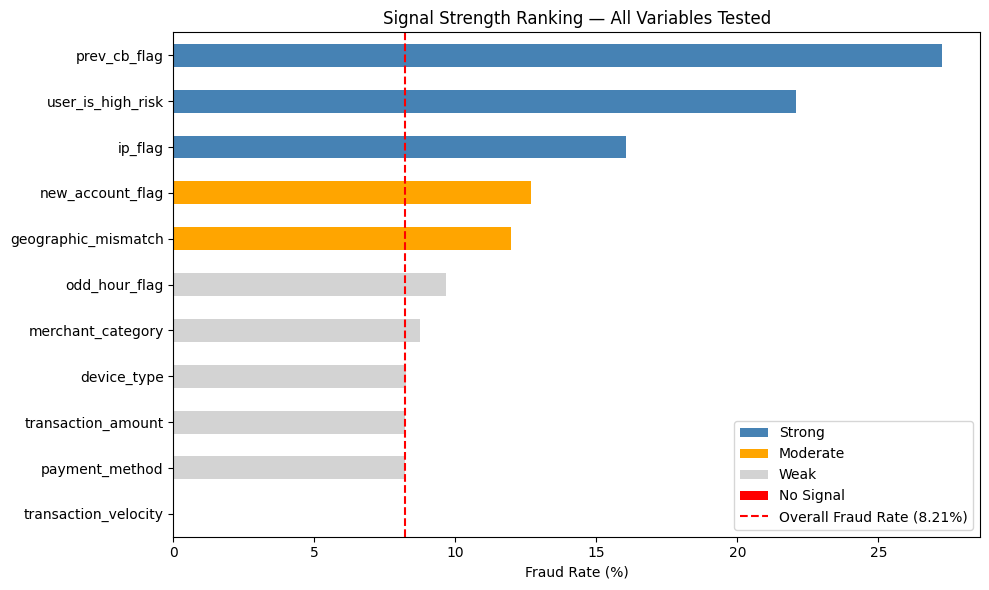

In [106]:
from matplotlib.patches import Patch

signal_ranking = pd.DataFrame({
    'signal': ['prev_cb_flag', 'user_is_high_risk', 'ip_flag', 
                'new_account_flag', 'geographic_mismatch', 'odd_hour_flag',
                'merchant_category', 'device_type', 'payment_method',
                'transaction_amount', 'transaction_velocity'],
    'fraud_rate': [27.24, 22.07, 16.05, 12.69, 11.96, 9.65, 
                   8.73, 8.24, 8.21, 8.21, 0.00],
    'strength': ['Strong', 'Strong', 'Strong', 'Moderate', 'Moderate',
                 'Weak', 'Weak', 'Weak', 'Weak', 'Weak', 'No Signal']
})

color_map = {
    'Strong': 'steelblue', 
    'Moderate': 'orange', 
    'Weak': 'lightgrey',
    'No Signal': 'red'
}

signal_sorted = signal_ranking.sort_values('fraud_rate')
colors = [color_map[s] for s in signal_sorted['strength']]

ax = signal_sorted.plot(
    kind='barh', x='signal', y='fraud_rate',
    figsize=(10, 6), legend=False, color=colors)

ax.set_title('Signal Strength Ranking — All Variables Tested')
ax.set_xlabel('Fraud Rate (%)')
ax.set_ylabel('')
ax.axvline(x=8.21, color='red', linestyle='--')

legend_elements = [
    Patch(facecolor='steelblue', label='Strong'),
    Patch(facecolor='orange', label='Moderate'),
    Patch(facecolor='lightgrey', label='Weak'),
    Patch(facecolor='red', label='No Signal'),
    plt.Line2D([0], [0], color='red', linestyle='--', 
               label='Overall Fraud Rate (8.21%)')
]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.savefig('17_signal_ranking.png', dpi=150)
plt.show()

### Insight
This chart consolidates all signals tested across the SQL and EDA phases 
into a single ranked visual, colour coded by predictive strength.

**Strong signals (steelblue):**
- prev_cb_flag (27.24%) — highest precision, fires rarely
- user_is_high_risk (22.07%) — strongest user-level signal, low coverage
- ip_flag (16.05%) — most balanced signal, available in real time

**Moderate signals (orange):**
- new_account_flag (12.69%) — high frequency, moderate precision
- geographic_mismatch (11.96%) — compounds with other signals

**Weak signals (grey):**
All cluster around the overall fraud rate with less than 1% spread. 
Not actionable as standalone rules.

**No signal:**
transaction_velocity never fires in this dataset.

This ranking serves as the feature priority guide for the ML phase. 
Strong and moderate signals are the primary candidates for the 
classification model. The 39.65% of fraud occurring in zero-flag 
transactions confirms that ML is not optional — it is the only way 
to close the coverage gap that rule-based systems cannot.

## EDA Summary and Transition to ML

### What EDA Confirmed from SQL
The visualizations validate the SQL signal ranking across all sections. 
IP risk score, user risk flag, geographic mismatch, and fraud flag 
combinations all show clear visual patterns consistent with SQL findings. 
Categorical variables — merchant category, device type, and payment method — 
confirmed as weak signals with near-identical fraud rates across all groups.

### What EDA Added Beyond SQL
The transaction amount KDE chart revealed a finding that contradicted the 
SQL average — fraudulent transactions actually cluster at lower amounts 
than legitimate ones. The SQL average was misleading due to outliers. 
This is a stronger and more nuanced finding than SQL alone could surface.

The correlation heatmap identified six redundant variable pairs that 
should be reduced before ML to avoid multicollinearity.

### Feature Selection for ML
Based on signal strength and correlation analysis, the following features 
are recommended for the classification model:

**Primary features:** ip_risk_score, user_is_high_risk, fraud_flag_prev_cb, 
fraud_flag_new_account, card_country_match, shipping_billing_match

**Supporting features:** odd_hour, user_account_age_days, amount_aed

**Drop from model:** fraud_flag_velocity (never fires), user_prev_chargebacks 
(redundant with fraud_flag_prev_cb), avg_item_price (redundant with amount_aed), 
local_hour (redundant with odd_hour), account_age_negative (redundant with 
fraud_flag_new_account), fraud_flag_mismatch (redundant with shipping_billing_match)

### The Core Limitation
39.65% of fraud occurs in transactions with zero flags fired. No combination 
of rules or thresholds identified in SQL or EDA can catch this segment. 
The ML classification model is the only way to identify subtle multi-variable 
patterns that distinguish these transactions from legitimate ones.

---
*Next phase: ML Classification Model — Phase 3*